# Phần 3 - Dự báo Doanh thu (Datathon)

Baseline này đã được chỉnh để đúng ràng buộc leakage: `Revenue` và `COGS` của tập train được dùng để tạo lag/rolling/recursive features, nhưng `Revenue`/`COGS` của test hoặc `sample_submission.csv` không được dùng làm feature. Khi cần `COGS` cùng ngày ở giai đoạn test/backtest, notebook dự báo `COGS` nội sinh từ lịch sử train rồi mới dùng giá trị dự báo đó.


## 1 - Import thư viện và cấu hình

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)


def resolve_paths() -> tuple[Path, Path]:
    """Tìm ROOT_DIR và DATA_DIR ổn định khi chạy notebook ở nhiều thư mục khác nhau."""
    candidates = [Path("."), Path(".."), Path("../..")] 

    for candidate in candidates:
        data_dir = candidate / "data"
        if (data_dir / "sales.csv").exists() and (data_dir / "sample_submission.csv").exists():
            return candidate.resolve(), data_dir.resolve()

    for candidate in candidates:
        if (candidate / "sales.csv").exists() and (candidate / "sample_submission.csv").exists():
            return candidate.resolve(), candidate.resolve()

    raise FileNotFoundError("Không tìm thấy thư mục dữ liệu chứa sales.csv và sample_submission.csv")


ROOT_DIR, DATA_DIR = resolve_paths()
TRAIN_FILE = DATA_DIR / "sales.csv"
TEST_FILE = DATA_DIR / "sales_test.csv"
SAMPLE_SUBMISSION_FILE = DATA_DIR / "sample_submission.csv"

OUTPUT_FILE_ROOT = ROOT_DIR / "submission.csv"
OUTPUT_DIR_REPORT = ROOT_DIR / "04_report_data"
OUTPUT_DIR_REPORT.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE_REPORT = OUTPUT_DIR_REPORT / "submission.csv"

print(f"THƯ MỤC GỐC (ROOT_DIR): {ROOT_DIR}")
print(f"THƯ MỤC DỮ LIỆU (DATA_DIR): {DATA_DIR}")

ROOT_DIR: D:\Project123456\HCMUS.RICONS---Datathon
DATA_DIR: D:\Project123456\HCMUS.RICONS---Datathon\data


## 2 - Đọc dữ liệu và kiểm tra đầu vào

In [ ]:
train = pd.read_csv(TRAIN_FILE, parse_dates=["Date"])

if TEST_FILE.exists():
    test = pd.read_csv(TEST_FILE, parse_dates=["Date"])
    test_source = TEST_FILE.name
else:
    test = pd.read_csv(SAMPLE_SUBMISSION_FILE, parse_dates=["Date"])
    test_source = f"{SAMPLE_SUBMISSION_FILE.name} (fallback vì chưa có sales_test.csv)"

required_train_cols = {"Date", "Revenue", "COGS"}
missing_train_cols = required_train_cols - set(train.columns)
if missing_train_cols:
    raise ValueError(f"File train thiếu cột: {missing_train_cols}")

required_test_cols = {"Date"}
missing_test_cols = required_test_cols - set(test.columns)
if missing_test_cols:
    raise ValueError(f"File test thiếu các cột bắt buộc cho pipeline này: {missing_test_cols}")

# Không dùng COGS/Revenue từ test hoặc sample_submission làm feature.
# Nếu các cột này có trong template, chúng chỉ được giữ để kiểm tra format, không đưa vào model.

train = train.sort_values("Date").reset_index(drop=True)
REFERENCE_START_DATE = train["Date"].min()

test["__row_id"] = np.arange(len(test))
test_sorted = test.sort_values("Date").reset_index(drop=True)

print("Kích thước train:", train.shape)
print("Khoảng ngày train:", train["Date"].min().date(), "->", train["Date"].max().date())
print("Ngày bắt đầu tham chiếu:", REFERENCE_START_DATE.date())
print()
print("Kích thước test:", test.shape)
print("Nguồn test:", test_source)
print("Khoảng ngày test:", test["Date"].min().date(), "->", test["Date"].max().date())
print()
print(train.head(3))
print(test.head(3))

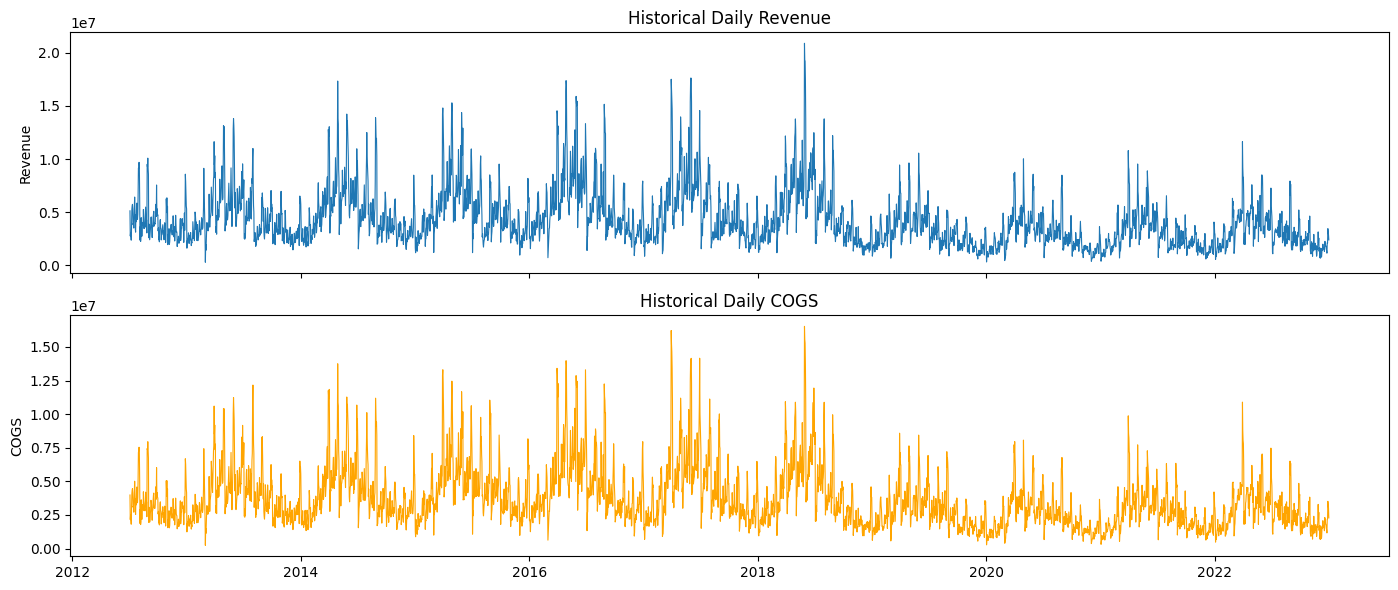

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(train["Date"], train["Revenue"], lw=0.8)
axes[0].set_title("Doanh thu lịch sử theo ngày")
axes[0].set_ylabel("Revenue")

axes[1].plot(train["Date"], train["COGS"], lw=0.8, color="orange")
axes[1].set_title("Giá vốn (COGS) lịch sử theo ngày")
axes[1].set_ylabel("COGS")

plt.tight_layout()
plt.show()

## 3 - Tạo đặc trưng và hàm mô hình

Baseline dùng calendar features, lag/rolling/EWM của `Revenue`, lag/rolling của `COGS`, và một vài tương tác đơn giản. Trong train, `COGS` cùng ngày được dùng hợp lệ vì đó là dữ liệu train. Trong validation/test, `COGS` cùng ngày không lấy từ future/test; hàm forecast sẽ tự dự báo `COGS` theo mùa vụ từ lịch sử đã biết.


In [14]:
LAG_STEPS = [1, 2, 3, 7, 14, 21, 28, 56, 84, 364, 365, 366]
ROLL_WINDOWS = [7, 14, 28, 56]
COGS_LAG_STEPS = [1, 7, 14, 28]
COGS_ROLL_WINDOWS = [7, 14, 28]

BASE_FEATURES = [
    "COGS",
    "year", "month", "day", "dayofweek", "weekofyear", "dayofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end", "is_payday_window",
    "days_from_start",
    "sin_doy", "cos_doy", "sin_dow", "cos_dow",
]

REV_LAG_FEATURES = [f"rev_lag_{lag}" for lag in LAG_STEPS]
REV_ROLL_FEATURES = [f"rev_roll_mean_{w}" for w in ROLL_WINDOWS] + [f"rev_roll_std_{w}" for w in ROLL_WINDOWS]
REV_EWM_FEATURES = ["rev_ewm_14", "rev_ewm_28"]

COGS_LAG_FEATURES = [f"cogs_lag_{lag}" for lag in COGS_LAG_STEPS]
COGS_ROLL_FEATURES = [f"cogs_roll_mean_{w}" for w in COGS_ROLL_WINDOWS]
COGS_DERIVED_FEATURES = ["cogs_pct_change_1", "cogs_x_dow"]

FEATURE_COLS = (
    BASE_FEATURES
    + REV_LAG_FEATURES
    + REV_ROLL_FEATURES
    + REV_EWM_FEATURES
    + COGS_LAG_FEATURES
    + COGS_ROLL_FEATURES
    + COGS_DERIVED_FEATURES
)


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["year"] = out["Date"].dt.year
    out["month"] = out["Date"].dt.month
    out["day"] = out["Date"].dt.day
    out["dayofweek"] = out["Date"].dt.dayofweek
    out["weekofyear"] = out["Date"].dt.isocalendar().week.astype(int)
    out["dayofyear"] = out["Date"].dt.dayofyear
    out["quarter"] = out["Date"].dt.quarter

    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["is_month_start"] = out["Date"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["Date"].dt.is_month_end.astype(int)
    out["is_payday_window"] = out["day"].isin([1, 2, 3, 28, 29, 30, 31]).astype(int)
    out["days_from_start"] = (out["Date"] - pd.Timestamp(REFERENCE_START_DATE)).dt.days.astype(int)

    out["sin_doy"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["cos_doy"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)
    out["sin_dow"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["cos_dow"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    return out


def build_supervised_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = add_calendar_features(df)

    for lag in LAG_STEPS:
        out[f"rev_lag_{lag}"] = out["Revenue"].shift(lag)

    shifted_rev = out["Revenue"].shift(1)
    for window in ROLL_WINDOWS:
        out[f"rev_roll_mean_{window}"] = shifted_rev.rolling(window).mean()
        out[f"rev_roll_std_{window}"] = shifted_rev.rolling(window).std()

    out["rev_ewm_14"] = shifted_rev.ewm(span=14, adjust=False).mean()
    out["rev_ewm_28"] = shifted_rev.ewm(span=28, adjust=False).mean()

    for lag in COGS_LAG_STEPS:
        out[f"cogs_lag_{lag}"] = out["COGS"].shift(lag)

    shifted_cogs = out["COGS"].shift(1)
    for window in COGS_ROLL_WINDOWS:
        out[f"cogs_roll_mean_{window}"] = shifted_cogs.rolling(window).mean()

    cogs_lag_1 = out["COGS"].shift(1).replace(0, np.nan)
    out["cogs_pct_change_1"] = ((out["COGS"] - cogs_lag_1) / cogs_lag_1).replace([np.inf, -np.inf], np.nan)
    out["cogs_x_dow"] = out["COGS"] * out["dayofweek"]

    return out.dropna().reset_index(drop=True)


def build_feature_row(
    current_date: pd.Timestamp,
    cogs_value: float,
    revenue_history: list[float],
    cogs_history: list[float],
) -> dict:
    date_df = pd.DataFrame({"Date": [current_date], "COGS": [cogs_value]})
    date_df = add_calendar_features(date_df)

    row = {feature: float(date_df.loc[0, feature]) for feature in BASE_FEATURES}

    rev_hist = pd.Series(revenue_history, dtype=float)
    rev_mean = float(rev_hist.mean()) if len(rev_hist) > 0 else 0.0

    for lag in LAG_STEPS:
        row[f"rev_lag_{lag}"] = float(rev_hist.iloc[-lag]) if len(rev_hist) >= lag else rev_mean

    for window in ROLL_WINDOWS:
        if len(rev_hist) >= window:
            vals = rev_hist.iloc[-window:]
            row[f"rev_roll_mean_{window}"] = float(vals.mean())
            row[f"rev_roll_std_{window}"] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        else:
            row[f"rev_roll_mean_{window}"] = rev_mean
            row[f"rev_roll_std_{window}"] = float(rev_hist.std(ddof=1)) if len(rev_hist) > 1 else 0.0

    row["rev_ewm_14"] = float(rev_hist.ewm(span=14, adjust=False).mean().iloc[-1]) if len(rev_hist) > 0 else 0.0
    row["rev_ewm_28"] = float(rev_hist.ewm(span=28, adjust=False).mean().iloc[-1]) if len(rev_hist) > 0 else 0.0

    cogs_hist = pd.Series(cogs_history, dtype=float)
    cogs_mean = float(cogs_hist.mean()) if len(cogs_hist) > 0 else float(cogs_value)

    for lag in COGS_LAG_STEPS:
        row[f"cogs_lag_{lag}"] = float(cogs_hist.iloc[-lag]) if len(cogs_hist) >= lag else cogs_mean

    for window in COGS_ROLL_WINDOWS:
        if len(cogs_hist) >= window:
            vals = cogs_hist.iloc[-window:]
            row[f"cogs_roll_mean_{window}"] = float(vals.mean())
        else:
            row[f"cogs_roll_mean_{window}"] = cogs_mean

    cogs_lag_1_val = row["cogs_lag_1"]
    denom = cogs_lag_1_val if abs(cogs_lag_1_val) > 1e-9 else 1.0
    row["cogs_pct_change_1"] = float((cogs_value - cogs_lag_1_val) / denom)
    row["cogs_x_dow"] = float(cogs_value * row["dayofweek"])

    return row

In [ ]:
CANDIDATE_HGB_PARAMS = [
    {
        "learning_rate": 0.04,
        "max_iter": 900,
        "max_depth": 8,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 800,
        "max_depth": 10,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 18,
        "l2_regularization": 0.05,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 1100,
        "max_depth": 8,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 24,
        "l2_regularization": 0.2,
    },
    {
        "learning_rate": 0.06,
        "max_iter": 700,
        "max_depth": 6,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 16,
        "l2_regularization": 0.0,
    },
]

XGB_BASE_PARAMS = {
    "n_estimators": 900,
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}

BLEND_WEIGHT_CANDIDATES = [0.4, 0.5, 0.6]


def make_model(seed: int = SEED, model_params: dict | None = None) -> HistGradientBoostingRegressor:
    """Model HGB cho dự báo doanh thu."""
    params = {
        "loss": "squared_error",
        "learning_rate": 0.04,
        "max_iter": 900,
        "max_depth": 8,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
    }
    if model_params is not None:
        params.update(model_params)

    return HistGradientBoostingRegressor(
        random_state=seed,
        **params,
    )


def make_xgb_model(seed: int = SEED, model_params: dict | None = None) -> XGBRegressor:
    """Model XGBoost dùng để ensemble với HGB."""
    params = dict(XGB_BASE_PARAMS)
    if model_params is not None:
        params.update(model_params)

    return XGBRegressor(
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        **params,
    )


def _series_value_at(series: pd.Series, date: pd.Timestamp) -> float | None:
    try:
        value = float(series.loc[date])
        return value if np.isfinite(value) else None
    except KeyError:
        return None


def forecast_next_cogs(
    current_date: pd.Timestamp,
    history_dates: list[pd.Timestamp],
    cogs_history: list[float],
) -> float:
    """Dự báo COGS từ lịch sử đã biết, không dùng COGS future/test."""
    series = pd.Series(cogs_history, index=pd.to_datetime(history_dates), dtype=float).sort_index()
    values = []
    weights = []

    for lag, weight in [(365, 0.42), (364, 0.22), (371, 0.10), (730, 0.26)]:
        value = _series_value_at(series, current_date - pd.Timedelta(days=lag))
        if value is not None:
            values.append(value)
            weights.append(weight)

    if values:
        pred = float(np.average(values, weights=weights))
    else:
        pred = float(series.tail(365).median())

    if len(series) >= 730:
        recent = float(series.tail(365).median())
        previous = float(series.iloc[-730:-365].median())
        growth = np.clip(recent / max(previous, 1.0), 0.90, 1.12)
        pred *= float(growth)

    recent_tail = series.tail(min(1095, len(series)))
    low = max(1.0, float(recent_tail.quantile(0.005) * 0.60))
    high = float(recent_tail.quantile(0.995) * 1.60)
    return float(np.clip(pred, low, high))


def recursive_forecast(
    model,
    history_df: pd.DataFrame,
    future_df: pd.DataFrame,
    feature_cols: list[str],
    log_target: bool = True,
    return_cogs: bool = False,
) -> np.ndarray | tuple[np.ndarray, np.ndarray]:
    revenue_history = history_df["Revenue"].astype(float).tolist()
    cogs_history = history_df["COGS"].astype(float).tolist()
    history_dates = pd.to_datetime(history_df["Date"]).tolist()
    preds = []
    cogs_preds = []

    for _, row in future_df.iterrows():
        current_date = pd.Timestamp(row["Date"])
        current_cogs = forecast_next_cogs(current_date, history_dates, cogs_history)
        feat = build_feature_row(
            current_date=current_date,
            cogs_value=current_cogs,
            revenue_history=revenue_history,
            cogs_history=cogs_history,
        )
        x = pd.DataFrame([feat], columns=feature_cols)
        raw_pred = float(model.predict(x)[0])

        y_hat = float(np.expm1(raw_pred)) if log_target else raw_pred
        y_hat = max(y_hat, 0.0)

        preds.append(y_hat)
        cogs_preds.append(current_cogs)
        revenue_history.append(y_hat)
        cogs_history.append(current_cogs)
        history_dates.append(current_date)

    revenue_array = np.array(preds)
    cogs_array = np.array(cogs_preds)
    if return_cogs:
        return revenue_array, cogs_array
    return revenue_array


def make_backtest_folds(df: pd.DataFrame, n_folds: int = 5, val_size: int = 150, min_train_size: int = 365 * 4):
    n = len(df)
    first_train_end = n - n_folds * val_size

    if first_train_end < min_train_size:
        raise ValueError(
            f"Not enough rows ({n}) for n_folds={n_folds}, val_size={val_size}, min_train_size={min_train_size}."
        )

    folds = []
    for i in range(n_folds):
        train_end = first_train_end + i * val_size
        val_start = train_end
        val_end = val_start + val_size

        folds.append((
            df.iloc[:train_end].copy(),
            df.iloc[val_start:val_end].copy(),
        ))

    return folds


def evaluate_time_cv(
    df: pd.DataFrame,
    feature_cols: list[str],
    model_params: dict | None = None,
    n_folds: int = 5,
    val_size: int = 150,
    log_target: bool = True,
):
    """Đánh giá model HGB đơn để tune tham số."""
    folds = make_backtest_folds(df, n_folds=n_folds, val_size=val_size)
    rows = []

    for i, (train_fold, val_fold) in enumerate(folds, start=1):
        train_supervised = build_supervised_frame(train_fold)
        X_train = train_supervised[feature_cols]
        y_train = train_supervised["Revenue"]

        model = make_model(seed=SEED + i, model_params=model_params)
        if log_target:
            model.fit(X_train, np.log1p(y_train))
        else:
            model.fit(X_train, y_train)

        y_pred = recursive_forecast(model, train_fold, val_fold, feature_cols, log_target=log_target)
        y_true = val_fold["Revenue"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        rows.append({
            "fold": i,
            "train_end": train_fold["Date"].max().date(),
            "val_start": val_fold["Date"].min().date(),
            "val_end": val_fold["Date"].max().date(),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })

    return pd.DataFrame(rows)


def run_hgb_param_search(
    df: pd.DataFrame,
    feature_cols: list[str],
    candidate_params: list[dict],
    n_folds: int = 4,
    val_size: int = 150,
) -> pd.DataFrame:
    summary_rows = []

    for i, params in enumerate(candidate_params, start=1):
        fold_scores = evaluate_time_cv(
            df=df,
            feature_cols=feature_cols,
            model_params=params,
            n_folds=n_folds,
            val_size=val_size,
            log_target=True,
        )

        summary_rows.append({
            "candidate_id": i,
            "MAE": fold_scores["MAE"].mean(),
            "RMSE": fold_scores["RMSE"].mean(),
            "R2": fold_scores["R2"].mean(),
            "params": str(params),
        })

    out = pd.DataFrame(summary_rows).sort_values(["MAE", "RMSE"], ascending=[True, True]).reset_index(drop=True)
    return out


def evaluate_blend_weight_candidates(
    df: pd.DataFrame,
    feature_cols: list[str],
    hgb_params: dict,
    blend_weights: list[float],
    xgb_params: dict | None = None,
    n_folds: int = 4,
    val_size: int = 150,
    log_target: bool = True,
):
    folds = make_backtest_folds(df, n_folds=n_folds, val_size=val_size)
    detail_rows = []

    for i, (train_fold, val_fold) in enumerate(folds, start=1):
        train_supervised = build_supervised_frame(train_fold)
        X_train = train_supervised[feature_cols]
        y_train = train_supervised["Revenue"]

        hgb_model = make_model(seed=SEED + i, model_params=hgb_params)
        xgb_model = make_xgb_model(seed=SEED + i, model_params=xgb_params)

        y_fit = np.log1p(y_train) if log_target else y_train
        hgb_model.fit(X_train, y_fit)
        xgb_model.fit(X_train, y_fit)

        pred_hgb = recursive_forecast(hgb_model, train_fold, val_fold, feature_cols, log_target=log_target)
        pred_xgb = recursive_forecast(xgb_model, train_fold, val_fold, feature_cols, log_target=log_target)
        y_true = val_fold["Revenue"].values

        for weight in blend_weights:
            pred_blend = weight * pred_hgb + (1 - weight) * pred_xgb
            detail_rows.append({
                "fold": i,
                "blend_weight_hgb": weight,
                "train_end": train_fold["Date"].max().date(),
                "val_start": val_fold["Date"].min().date(),
                "val_end": val_fold["Date"].max().date(),
                "MAE": mean_absolute_error(y_true, pred_blend),
                "RMSE": np.sqrt(mean_squared_error(y_true, pred_blend)),
                "R2": r2_score(y_true, pred_blend),
            })

    detail_df = pd.DataFrame(detail_rows)
    summary_df = (
        detail_df.groupby("blend_weight_hgb")[["MAE", "RMSE", "R2"]]
        .mean()
        .reset_index()
        .sort_values(["MAE", "RMSE"], ascending=[True, True])
        .reset_index(drop=True)
    )

    return summary_df, detail_df


def evaluate_blend_cv(
    df: pd.DataFrame,
    feature_cols: list[str],
    hgb_params: dict,
    blend_weight_hgb: float,
    xgb_params: dict | None = None,
    n_folds: int = 5,
    val_size: int = 150,
    log_target: bool = True,
):
    folds = make_backtest_folds(df, n_folds=n_folds, val_size=val_size)
    rows = []

    for i, (train_fold, val_fold) in enumerate(folds, start=1):
        train_supervised = build_supervised_frame(train_fold)
        X_train = train_supervised[feature_cols]
        y_train = train_supervised["Revenue"]

        hgb_model = make_model(seed=SEED + i, model_params=hgb_params)
        xgb_model = make_xgb_model(seed=SEED + i, model_params=xgb_params)

        y_fit = np.log1p(y_train) if log_target else y_train
        hgb_model.fit(X_train, y_fit)
        xgb_model.fit(X_train, y_fit)

        pred_hgb = recursive_forecast(hgb_model, train_fold, val_fold, feature_cols, log_target=log_target)
        pred_xgb = recursive_forecast(xgb_model, train_fold, val_fold, feature_cols, log_target=log_target)
        pred_blend = blend_weight_hgb * pred_hgb + (1 - blend_weight_hgb) * pred_xgb

        y_true = val_fold["Revenue"].values

        rows.append({
            "fold": i,
            "train_end": train_fold["Date"].max().date(),
            "val_start": val_fold["Date"].min().date(),
            "val_end": val_fold["Date"].max().date(),
            "MAE": mean_absolute_error(y_true, pred_blend),
            "RMSE": np.sqrt(mean_squared_error(y_true, pred_blend)),
            "R2": r2_score(y_true, pred_blend),
        })

    return pd.DataFrame(rows)

## 4 - Cross-validation theo thời gian (an toàn leakage)

Parameter search summary (sorted by MAE then RMSE):


,candidate_id,MAE,RMSE,R2,params
0,4,220663.333047,356518.642317,0.922937,"{'learning_rate': 0.06, 'max_iter': 700, 'max_..."
1,1,228230.480609,365832.101970,0.917225,"{'learning_rate': 0.04, 'max_iter': 900, 'max_..."
2,2,232150.468394,363844.847522,0.920072,"{'learning_rate': 0.05, 'max_iter': 800, 'max_..."
3,3,237376.184648,382173.383107,0.911995,"{'learning_rate': 0.03, 'max_iter': 1100, 'max..."


Selected best candidate: 4
Selected params: {'learning_rate': 0.06, 'max_iter': 700, 'max_depth': 6, 'max_leaf_nodes': 63, 'min_samples_leaf': 16, 'l2_regularization': 0.0}

Per-fold results with selected params:


,fold,train_end,val_start,val_end,MAE,RMSE,R2
0,1,2020-12-11,2020-12-12,2021-05-10,107783.296221,152961.981049,0.993044
1,2,2021-05-10,2021-05-11,2021-10-07,419472.355902,666360.393019,0.811162
2,3,2021-10-07,2021-10-08,2022-03-06,123133.517473,195692.873006,0.961626
3,4,2022-03-06,2022-03-07,2022-08-03,202928.134874,304106.567694,0.963424
4,5,2022-08-03,2022-08-04,2022-12-31,137119.323941,259914.735551,0.955537



CV summary:


,metric,mean,std
0,MAE,198087.325682,128961.964719
1,RMSE,315807.310064,204385.928086
2,R2,0.936959,0.071806


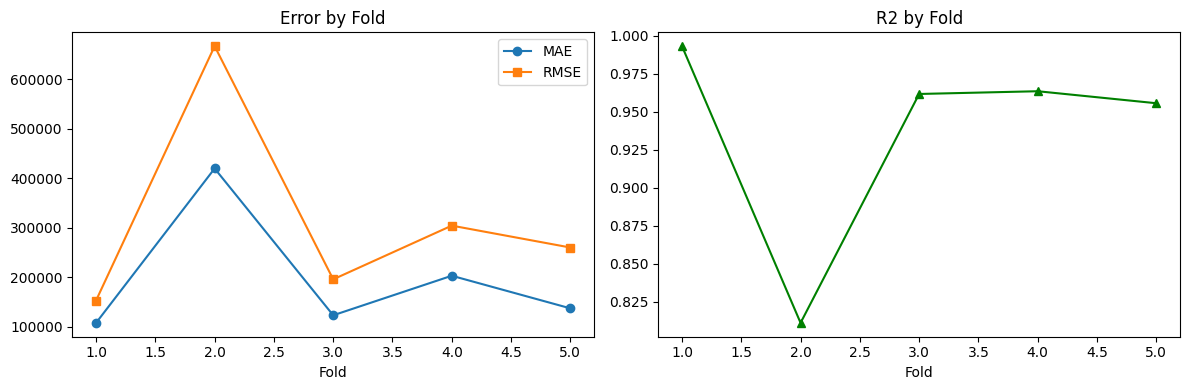

In [ ]:
search_results = run_hgb_param_search(
    df=train,
    feature_cols=FEATURE_COLS,
    candidate_params=CANDIDATE_HGB_PARAMS,
    n_folds=4,
    val_size=150,
)

print("Tổng hợp tìm kiếm tham số HGB (sắp xếp theo MAE rồi RMSE):")
display(search_results)

BEST_CANDIDATE_ID = int(search_results.iloc[0]["candidate_id"])
BEST_HGB_PARAMS = CANDIDATE_HGB_PARAMS[BEST_CANDIDATE_ID - 1]
BEST_XGB_PARAMS = dict(XGB_BASE_PARAMS)

print("Mã cấu hình HGB tốt nhất:", BEST_CANDIDATE_ID)
print("Tham số HGB đã chọn:", BEST_HGB_PARAMS)
print("Tham số XGB sử dụng:", BEST_XGB_PARAMS)

blend_search_summary, blend_search_detail = evaluate_blend_weight_candidates(
    df=train,
    feature_cols=FEATURE_COLS,
    hgb_params=BEST_HGB_PARAMS,
    xgb_params=BEST_XGB_PARAMS,
    blend_weights=BLEND_WEIGHT_CANDIDATES,
    n_folds=4,
    val_size=150,
    log_target=True,
)

print("\nKết quả tìm trọng số ensemble (HGB + XGB):")
display(blend_search_summary)

BEST_BLEND_WEIGHT = float(blend_search_summary.iloc[0]["blend_weight_hgb"])
print("Trọng số HGB tốt nhất:", BEST_BLEND_WEIGHT)
print("Trọng số XGB tốt nhất:", round(1 - BEST_BLEND_WEIGHT, 3))

cv_results = evaluate_blend_cv(
    df=train,
    feature_cols=FEATURE_COLS,
    hgb_params=BEST_HGB_PARAMS,
    xgb_params=BEST_XGB_PARAMS,
    blend_weight_hgb=BEST_BLEND_WEIGHT,
    n_folds=5,
    val_size=150,
    log_target=True,
)

print("\nKết quả theo từng fold với mô hình ensemble đã chọn:")
display(cv_results)

cv_summary = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "mean": [cv_results["MAE"].mean(), cv_results["RMSE"].mean(), cv_results["R2"].mean()],
        "std": [cv_results["MAE"].std(ddof=1), cv_results["RMSE"].std(ddof=1), cv_results["R2"].std(ddof=1)],
    }
)

print("\nTóm tắt CV:")
display(cv_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cv_results["fold"], cv_results["MAE"], marker="o", label="MAE")
axes[0].plot(cv_results["fold"], cv_results["RMSE"], marker="s", label="RMSE")
axes[0].set_title("Sai số theo từng fold")
axes[0].set_xlabel("Fold")
axes[0].legend()

axes[1].plot(cv_results["fold"], cv_results["R2"], marker="^", color="green")
axes[1].set_title("R2 theo từng fold")
axes[1].set_xlabel("Fold")

plt.tight_layout()
plt.show()

## 5 - Huấn luyện mô hình cuối và dự báo tập test

Model cuối được fit lại trên toàn bộ train. Khi forecast test, notebook tạo `COGS_pred` tuần tự từ train history rồi dùng `COGS_pred` làm feature cho Revenue. File submission vẫn giữ đúng thứ tự dòng ban đầu thông qua `__row_id`.


In [ ]:
train_supervised_full = build_supervised_frame(train)
X_full = train_supervised_full[FEATURE_COLS]
y_full = train_supervised_full["Revenue"]

final_hgb_model = make_model(seed=SEED, model_params=BEST_HGB_PARAMS)
final_xgb_model = make_xgb_model(seed=SEED, model_params=BEST_XGB_PARAMS)

final_hgb_model.fit(X_full, np.log1p(y_full))
final_xgb_model.fit(X_full, np.log1p(y_full))

# Dùng HGB (raw target) để tạo artifact giải thích dễ đọc hơn.
explain_model = make_model(seed=SEED, model_params=BEST_HGB_PARAMS)
explain_model.fit(X_full, y_full)

pred_test_hgb, pred_test_cogs = recursive_forecast(
    model=final_hgb_model,
    history_df=train,
    future_df=test_sorted,
    feature_cols=FEATURE_COLS,
    log_target=True,
    return_cogs=True,
)

pred_test_xgb = recursive_forecast(
    model=final_xgb_model,
    history_df=train,
    future_df=test_sorted,
    feature_cols=FEATURE_COLS,
    log_target=True,
)

pred_test_sorted = BEST_BLEND_WEIGHT * pred_test_hgb + (1 - BEST_BLEND_WEIGHT) * pred_test_xgb

test_sorted = test_sorted.copy()
test_sorted["Revenue_pred"] = pred_test_sorted

test_sorted["COGS_pred"] = pred_test_cogs

submission = (
    test_sorted[["Date", "Revenue_pred", "COGS_pred", "__row_id"]]
    .rename(columns={"Revenue_pred": "Revenue", "COGS_pred": "COGS"})
    .sort_values("__row_id")
    .drop(columns="__row_id")
    .reset_index(drop=True)
)

submission["Revenue"] = submission["Revenue"].clip(lower=0).round(2)
submission["COGS"] = pd.to_numeric(submission["COGS"], errors="coerce").clip(lower=0).round(2)
if submission["COGS"].isna().any():
    raise ValueError("COGS_pred có giá trị thiếu. Vui lòng kiểm tra lại bước dự báo COGS nội sinh.")
submission["Date"] = pd.to_datetime(submission["Date"]).dt.strftime("%Y-%m-%d")

submission.to_csv(OUTPUT_FILE_ROOT, index=False)
submission.to_csv(OUTPUT_FILE_REPORT, index=False)

print(f"Đã lưu submission tại: {OUTPUT_FILE_ROOT}")
print(f"Đã lưu submission tại: {OUTPUT_FILE_REPORT}")
print("Kích thước submission:", submission.shape)
print("COGS trong submission là COGS_pred nội sinh, không copy từ test/template.")
submission.head(10)

## 6 - Giải thích mô hình (Feature Importance + Partial Dependence)

Top features by permutation importance:


,feature,importance_mean,importance_std
0,COGS,1.416668e+06,24888.538852
1,rev_lag_1,3.286976e+05,5445.803751
2,cogs_pct_change_1,8.913618e+04,2720.312992
3,cogs_lag_1,6.360422e+04,1606.594434
4,sin_doy,5.396950e+04,1764.583444
5,dayofyear,4.891014e+04,1063.550515
6,rev_roll_mean_7,4.388043e+04,2272.181828
7,cos_doy,4.367791e+04,1628.000792
8,days_from_start,2.210782e+04,1027.281127
9,cogs_roll_mean_7,1.669077e+04,815.614126


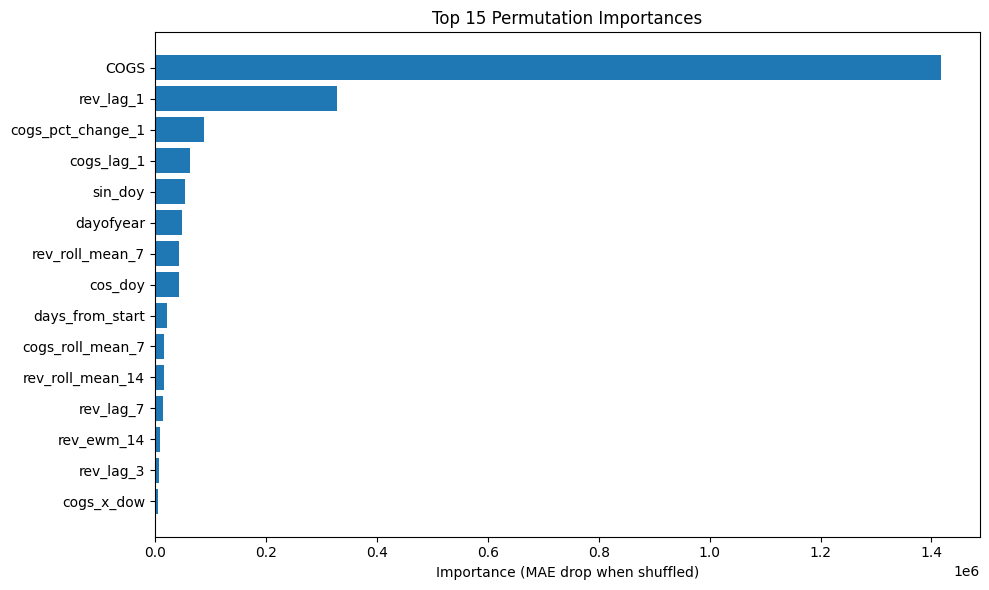

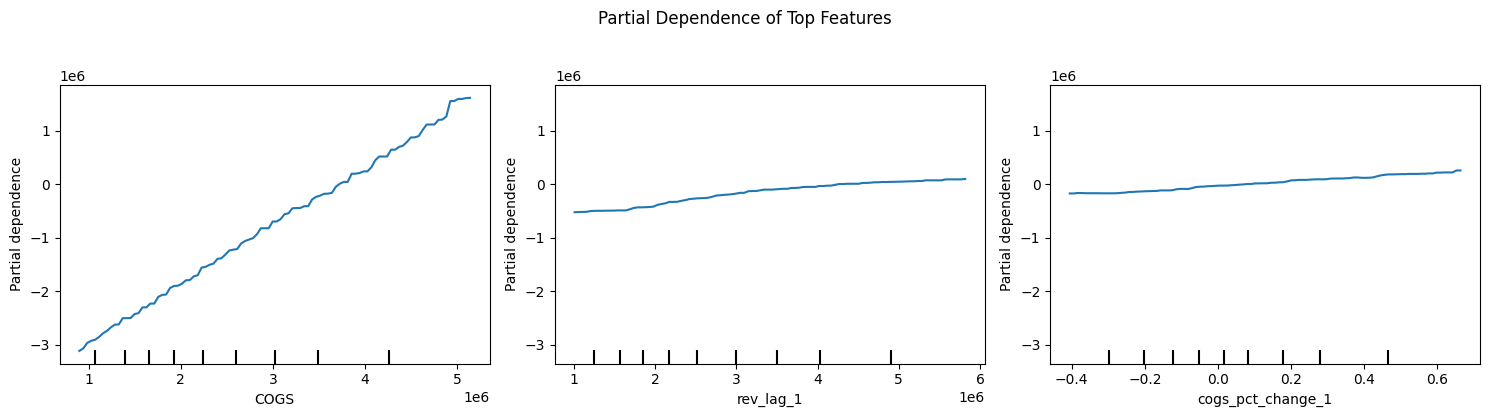

In [ ]:
explain_df = train_supervised_full.tail(min(1200, len(train_supervised_full))).copy()
X_explain = explain_df[FEATURE_COLS]
y_explain = explain_df["Revenue"]

perm_result = permutation_importance(
    explain_model,
    X_explain,
    y_explain,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_mean_absolute_error",
)

importance_df = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLS,
            "importance_mean": perm_result.importances_mean,
            "importance_std": perm_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Top biến theo permutation importance:")
display(importance_df.head(15))

plt.figure(figsize=(10, 6))
plot_df = importance_df.head(15).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Top 15 biến quan trọng (Permutation Importance)")
plt.xlabel("Mức độ quan trọng (mức giảm MAE khi xáo trộn biến)")
plt.tight_layout()
plt.show()

top_pdp_features = importance_df.loc[:2, "feature"].tolist()

fig, ax = plt.subplots(1, len(top_pdp_features), figsize=(5 * len(top_pdp_features), 4))
if len(top_pdp_features) == 1:
    ax = [ax]

PartialDependenceDisplay.from_estimator(
    explain_model,
    X_explain,
    features=top_pdp_features,
    ax=ax,
)

plt.suptitle("Partial Dependence cho các biến quan trọng nhất", y=1.03)
plt.tight_layout()
plt.show()

## 7 - Diễn giải kinh doanh và checklist ràng buộc

Checklist chính: cross-validation theo thời gian, không shuffle; dùng `Revenue/COGS` train để tạo feature; không dùng `Revenue/COGS` test làm feature; submission giữ đúng thứ tự như sample; mã có seed để tái lập. Baseline này vẫn đơn giản hơn notebook chính, nhưng đã hết lỗi leakage COGS test.


In [ ]:
cv_results_path = OUTPUT_DIR_REPORT / "cv_results.csv"
importance_path = OUTPUT_DIR_REPORT / "feature_importance.csv"
search_results_path = OUTPUT_DIR_REPORT / "hgb_model_search_results.csv"
blend_search_summary_path = OUTPUT_DIR_REPORT / "blend_weight_search_summary.csv"
blend_search_detail_path = OUTPUT_DIR_REPORT / "blend_weight_search_detail.csv"
best_model_config_path = OUTPUT_DIR_REPORT / "best_model_config.csv"

cv_results.to_csv(cv_results_path, index=False)
importance_df.to_csv(importance_path, index=False)
search_results.to_csv(search_results_path, index=False)
blend_search_summary.to_csv(blend_search_summary_path, index=False)
blend_search_detail.to_csv(blend_search_detail_path, index=False)

pd.DataFrame(
    [
        {
            "best_hgb_candidate_id": BEST_CANDIDATE_ID,
            "best_hgb_params": str(BEST_HGB_PARAMS),
            "xgb_params": str(BEST_XGB_PARAMS),
            "best_blend_weight_hgb": BEST_BLEND_WEIGHT,
            "best_blend_weight_xgb": 1 - BEST_BLEND_WEIGHT,
        }
    ]
).to_csv(best_model_config_path, index=False)

print("Đã lưu kết quả CV tại:", cv_results_path)
print("Đã lưu feature importance tại:", importance_path)
print("Đã lưu kết quả search tham số HGB tại:", search_results_path)
print("Đã lưu tóm tắt search trọng số blend tại:", blend_search_summary_path)
print("Đã lưu chi tiết search trọng số blend tại:", blend_search_detail_path)
print("Đã lưu cấu hình mô hình tốt nhất tại:", best_model_config_path)

# Kiểm tra thứ tự dòng theo sample_submission khi số dòng bằng nhau.
if SAMPLE_SUBMISSION_FILE.exists():
    sample_order = pd.read_csv(SAMPLE_SUBMISSION_FILE)["Date"].astype(str).tolist()
    current_order = submission["Date"].astype(str).tolist()

    if len(sample_order) == len(current_order):
        order_ok = sample_order == current_order
        print("Thứ tự Date khớp sample_submission.csv:", order_ok)
    else:
        print("Bỏ qua kiểm tra thứ tự tuyệt đối vì số dòng khác sample_submission.csv")

print("\nĐiểm CV trung bình cuối cùng:")
print("MAE :", round(cv_results["MAE"].mean(), 4))
print("RMSE:", round(cv_results["RMSE"].mean(), 4))
print("R2  :", round(cv_results["R2"].mean(), 4))
print("Mã cấu hình HGB tốt nhất:", BEST_CANDIDATE_ID)
print("Trọng số blend (HGB, XGB):", (round(BEST_BLEND_WEIGHT, 3), round(1 - BEST_BLEND_WEIGHT, 3)))

submission.head(5)

In [ ]:
print('--- Tóm tắt nhanh ---')
print('Mã cấu hình HGB tốt nhất:', BEST_CANDIDATE_ID)
print('Tham số HGB đã chọn:', BEST_HGB_PARAMS)
print('Tham số XGB sử dụng:', BEST_XGB_PARAMS)
print('Trọng số blend (HGB, XGB):', (round(BEST_BLEND_WEIGHT, 3), round(1 - BEST_BLEND_WEIGHT, 3)))
print('CV mean MAE :', round(cv_results['MAE'].mean(), 4))
print('CV mean RMSE:', round(cv_results['RMSE'].mean(), 4))
print('CV mean R2  :', round(cv_results['R2'].mean(), 4))

print('Số dòng submission:', len(submission))
print('Các cột submission:', list(submission.columns))
print('File output root tồn tại:', OUTPUT_FILE_ROOT.exists(), OUTPUT_FILE_ROOT)
print('File output report tồn tại:', OUTPUT_FILE_REPORT.exists(), OUTPUT_FILE_REPORT)

if SAMPLE_SUBMISSION_FILE.exists() and len(pd.read_csv(SAMPLE_SUBMISSION_FILE)) == len(submission):
    same_order = (
        pd.read_csv(SAMPLE_SUBMISSION_FILE)['Date'].astype(str).tolist()
        == submission['Date'].astype(str).tolist()
    )
    print('Thứ tự Date khớp sample_submission.csv:', same_order)
else:
    print('Bỏ qua kiểm tra thứ tự (khác số dòng hoặc thiếu sample file).')

print('COGS output là dự báo nội sinh, không dùng COGS test làm feature.')
print('Top 5 feature quan trọng:', importance_df.head(5)['feature'].tolist())

submission.head(3)